# 숙제 3

데이터과학 입문

박성우 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 참고

이 파일(`hw03.qmd`)의 setup 청크는 작성자의 로컬 환경에 맞춰
`reticulate`를 설정해 두었다. `RETICULATE_PYTHON` 환경변수가 잡혀
있으면(GitHub Actions나 컨테이너 안에서) 그 인터프리터를 쓰고, 없으면
로컬 pyenv anaconda 환경으로 떨어지도록 분기해 두었으니, 다른 환경에서
컴파일할 때는 이 부분과 `.Rprofile`을 본인 환경에 맞게 고치면 된다.

분석 코드는 R과 Python을 함께 작성하는 것을 원칙으로 했다. 로지스틱
회귀, 포아송 회귀, 비선형 최소제곱(`nls`)까지는 강의록(MASS)에 R과
Python(`statsmodels`, `scipy`) 예시가 나란히 실려 있어 두 언어로 적었다.
다만 음이항 회귀(`glm.nb`)만은 강의록에서 R로만 다루고 Python 코드가
따로 없어(문제 2-3 (2)), 그 부분은 R로만 작성했다.

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

`NHANES` 자료에서 20세 이상 성인을 두고 “지금 담배를 피우는가”를
예측하는 로지스틱 회귀를 세우는 문제이다. `SmokeNow`(현재 흡연 여부)는
평생 담배를 100개비 넘게 피워 본 사람한테만 물어본 항목이라, 100개비를
채운 적 없는 사람은 전부 결측으로 비어 있다. 이걸 그냥 두면 표본이
“한때라도 담배깨나 피운 사람”으로 쪼그라들어서 비흡연의 기준 자체가
이상해진다. 그래서 100개비 미만인 사람(`Smoke100 == "No"`)은 현재
비흡연(0)으로 다시 코딩해 줘야 반응변수가 제대로 완성된다.

우선 `Smoke100`과 `SmokeNow`를 교차표로 찍어 결측이 어디서 생기는지 본
다음, 그 구조에 맞춰 `currentSmoker`를 만들었다.

## R

``` r
library(tidyverse)
library(NHANES)
library(MASS)

nhanes_df <- NHANES::NHANES

# 20세 이상에서 SmokeNow와 Smoke100의 결측 구조 확인
nhanes_df %>%
    filter(Age >= 20) %>%
    count(Smoke100, SmokeNow)
```

    # A tibble: 3 × 3
      Smoke100 SmokeNow     n
      <fct>    <fct>    <int>
    1 No       <NA>      4024
    2 Yes      No        1745
    3 Yes      Yes       1466

``` r
adult <- nhanes_df %>%
    filter(Age >= 20) %>%
    mutate(currentSmoker = case_when(
        SmokeNow == "Yes" ~ 1L,
        SmokeNow == "No" ~ 0L,
        Smoke100 == "No" ~ 0L,
        TRUE ~ NA_integer_
    )) %>%
    filter(!is.na(currentSmoker)) %>%
    dplyr::select(currentSmoker, Age, Gender, Race1, Education, Poverty, BMI)

cat("관측치:", nrow(adult), " 현재 흡연율:", round(mean(adult$currentSmoker), 3), "\n")
```

    관측치: 7235  현재 흡연율: 0.203 

## Python

``` python
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# R에서 정리한 adult 데이터프레임을 reticulate로 그대로 받아 사용
adult = r.adult.copy()
print("관측치:", len(adult), " 현재 흡연율:", round(adult["currentSmoker"].mean(), 3))
```

    관측치: 7235  현재 흡연율: 0.203

20세 이상 7,235명 가운데 1,466명이 현재 흡연자라 흡연율은 20.3% 정도다.

이제 나이, 성별, 인종, 교육수준, 빈곤지표(`Poverty`),
체질량지수(`BMI`)를 넣어 로지스틱 회귀를 적합하고 AIC 기준 단계별
선택으로 변수를 정리했다. R에서 요인의 기준수준(여성, Black, 8th
Grade)이 자동으로 잡히는데, Python에서도 똑같은 기준을 쓰도록
`Treatment(reference=...)`로 일일이 맞췄다.

## R

``` r
fit_smoke <- glm(
    currentSmoker ~ Age + Gender + Race1 + Education + Poverty + BMI,
    data = adult, family = binomial
)
fit_smoke_step <- stepAIC(fit_smoke, trace = FALSE)

# 단계별 선택
formula(fit_smoke_step)
```

    currentSmoker ~ Age + Gender + Race1 + Education + Poverty + 
        BMI

``` r
round(summary(fit_smoke_step)$coef, 4)
```

                            Estimate Std. Error  z value Pr(>|z|)
    (Intercept)               1.4305     0.2501   5.7208   0.0000
    Age                      -0.0214     0.0020 -10.4717   0.0000
    Gendermale                0.3378     0.0655   5.1548   0.0000
    Race1Hispanic            -0.5777     0.1681  -3.4371   0.0006
    Race1Mexican             -0.9722     0.1584  -6.1380   0.0000
    Race1White                0.1180     0.1021   1.1559   0.2477
    Race1Other               -0.0358     0.1540  -0.2324   0.8162
    Education9 - 11th Grade   0.3979     0.1528   2.6048   0.0092
    EducationHigh School     -0.1292     0.1507  -0.8579   0.3910
    EducationSome College    -0.4432     0.1510  -2.9359   0.0033
    EducationCollege Grad    -1.3532     0.1682  -8.0468   0.0000
    Poverty                  -0.1837     0.0229  -8.0249   0.0000
    BMI                      -0.0378     0.0052  -7.2925   0.0000

``` r
round(exp(coef(fit_smoke_step)), 3)
```

                (Intercept)                     Age              Gendermale 
                      4.181                   0.979                   1.402 
              Race1Hispanic            Race1Mexican              Race1White 
                      0.561                   0.378                   1.125 
                 Race1Other Education9 - 11th Grade    EducationHigh School 
                      0.965                   1.489                   0.879 
      EducationSome College   EducationCollege Grad                 Poverty 
                      0.642                   0.258                   0.832 
                        BMI 
                      0.963 

``` r
# 0.5 절단값으로 만든 혼동행렬 (예측모형 관점의 분류 성능)
adult_used <- fit_smoke_step$model
pred_yes <- predict(fit_smoke_step, type = "response") > 0.5
table(observed = adult_used$currentSmoker, predicted = pred_yes)
```

            predicted
    observed FALSE TRUE
           0  5217   87
           1  1201  127

## Python

``` python
# R의 요인 기준수준과 동일하게: Gender=female, Race1=Black, Education='8th Grade'
formula = (
    "currentSmoker ~ Age "
    "+ C(Gender, Treatment(reference='female')) "
    "+ C(Race1, Treatment(reference='Black')) "
    "+ C(Education, Treatment(reference='8th Grade')) "
    "+ Poverty + BMI"
)
fit_smoke = smf.glm(formula, data=adult, family=sm.families.Binomial()).fit()

# 계수
coef_tbl = pd.DataFrame({
    "estimate": fit_smoke.params,
    "odds_ratio": np.exp(fit_smoke.params),
    "p_value": fit_smoke.pvalues,
})
print(coef_tbl.round(4))
```

                                                        estimate  ...  p_value
    Intercept                                             1.4305  ...   0.0000
    C(Gender, Treatment(reference='female'))[T.male]      0.3378  ...   0.0000
    C(Race1, Treatment(reference='Black'))[T.Hispanic]   -0.5777  ...   0.0006
    C(Race1, Treatment(reference='Black'))[T.Mexican]    -0.9722  ...   0.0000
    C(Race1, Treatment(reference='Black'))[T.White]       0.1180  ...   0.2477
    C(Race1, Treatment(reference='Black'))[T.Other]      -0.0358  ...   0.8162
    C(Education, Treatment(reference='8th Grade'))[...    0.3979  ...   0.0092
    C(Education, Treatment(reference='8th Grade'))[...   -0.1292  ...   0.3910
    C(Education, Treatment(reference='8th Grade'))[...   -0.4432  ...   0.0033
    C(Education, Treatment(reference='8th Grade'))[...   -1.3532  ...   0.0000
    Age                                                  -0.0214  ...   0.0000
    Poverty                                              -0.1837  ...   0.0000
    BMI                                                  -0.0378  ...   0.0000

    [13 rows x 3 columns]

``` python
print("\nAIC:", round(fit_smoke.aic, 1), " n:", int(fit_smoke.nobs))
```


    AIC: 5975.5  n: 6632

``` python
# 0.5 절단값 혼동행렬
pred_yes = (fit_smoke.predict() > 0.5).astype(int)
print("\n", pd.crosstab(fit_smoke.model.endog.astype(int), pred_yes,
                        rownames=["observed"], colnames=["predicted"]))
```


     predicted     0    1
    observed            
    0          5217   87
    1          1201  127

`stepAIC`는 후보 여섯 개를 하나도 떨어뜨리지 않았다. 출력 표만 보면
Python 쪽은 patsy가 `C()`로 감싼 범주형 항을 먼저 늘어놓아 행 순서가 R과
달라 보이는데, 값 자체는 그대로다.

해석은 오즈비로 확인했다. 나이가 한 살 들 때마다 현재 흡연 오즈가
0.98배로 조금씩 깎이고(나이 들수록 끊었거나 애초에 안 피우는 비율이
높다), 남성은 여성보다 흡연 오즈가 1.40배다. 교육수준이 큰 차이를
보인다. 대졸자(College Grad)는 기준집단인 중졸(8th Grade)에 견줘 흡연
오즈가 0.26배, 그러니까 4분의 1 수준으로 뚝 떨어진다. 빈곤지표는 값이
클수록(덜 가난할수록) 0.83배씩 낮아지고 BMI도 한 단위당 0.96배로
미세하게 음의 방향이다. 인종에서는 Mexican(0.38배)과 Hispanic(0.56배)이
기준보다 흡연 오즈가 뚜렷하게 낮았다. 교육과 사회경제적 지위가 흡연을
강하게 가르는 변수임을 볼 수 있다.

다만 잘 맞는 모형과 잘 맞히는 모형은 다른 얘기다. 흡연율이 20% 남짓이라
0.5를 절단값으로 쓰면 모형이 사실상 거의 모두를 비흡연으로 찍어 버린다.
혼동행렬은 `BMI`나 `Poverty`에 결측이 있는 행을 `glm`이 알아서 떨군
완전관측 6,632명 기준인데, 그중 실제 흡연자 1,328명 가운데 127명만
흡연으로 잡아냈다. 정확도는 80% 가까이 나와 그럴싸해 보여도 민감도는
형편없다는 뜻이다. 이렇게 한쪽으로 쏠린 자료에서는 절단값을 낮추거나 ROC
곡선으로 절단값 전체를 훑어보는 편이, 정확도 하나만 들이미는 것보다
모형을 정직하게 평가하는 방법이다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

`Teams`에서 2010–2025년 중 2020년만 뺀 구간을 추려, 팀-시즌 하나를 한
행으로 두고 득점 `RS = R`, 실점 `RA`, 승률 `WPct = W/(W+L)`을 계산했다.
팀 자료는 한 시즌에 (팀, 연도)가 자연스럽게 유일해서, 선수 자료처럼 이적
때문에 같은 키가 두 번 찍히는 문제가 없다. 로그 득실비
`lr = log(RS/RA)`는 뒤의 로지스틱 회귀에서 설명변수로 쓰려고 여기서 미리
만들어 뒀다. 박스스코어 변수 묶음(`vars_box`)도 문제 2-2 이후에서
재활용하려고 한 번에 정의해 둔다.

## R

``` r
library(tidyverse)
library(Lahman)
library(MASS)

# 박스스코어 설명변수 (문제 2-2 이후에서 재사용)
vars_box <- c(
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
)

# 2010-2025 (2020 제외) 팀-시즌 자료
recent <- Teams %>%
    filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
    mutate(
        RS = R,
        WPct = W / (W + L),
        logRS = log(R),
        logRA = log(RA),
        lr = log(RS / RA)
    ) %>%
    dplyr::select(
        yearID, teamID, lgID, W, L, G, WPct, RS, RA,
        logRS, logRA, lr, all_of(vars_box)
    )

cat("관측치:", nrow(recent), " 연도:", paste(range(recent$yearID), collapse = "-"), "\n")
```

    관측치: 450  연도: 2010-2025 

## Python

``` python
import polars as pl

# R에서 정리한 recent를 reticulate로 그대로 받음 (열 이름, 수록 연도까지 R과 동일)
recent = r.recent.copy()
print("관측치:", len(recent), " 연도:", recent["yearID"].min(), "-", recent["yearID"].max())
```

    관측치: 450  연도: 2010 - 2025

#### (1) Bill James 모형의 비선형 최소제곱 적합

`nls()` 방식을 사용해 $WPct = 1/(1+(RA/RS)^k)$를 적합했다. 비선형 모수
$k$의 신뢰구간은 R에서는 프로파일 우도 기반의 `confint()`로,
Python에서는 `curve_fit`이 돌려주는 공분산행렬에서 Wald 방식으로 뽑았다.

## R

``` r
fit_nls <- nls(WPct ~ 1 / (1 + (RA / RS)^k), data = recent, start = list(k = 2))
coef(fit_nls)
```

           k 
    1.752794 

``` r
confint(fit_nls)
```

        2.5%    97.5% 
    1.695234 1.810559 

## Python

``` python
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats

def bill_james(ratio, k):
    # ratio = RA / RS
    return 1 / (1 + ratio**k)

ratio = (recent["RA"] / recent["RS"]).to_numpy()
popt, pcov = curve_fit(bill_james, ratio, recent["WPct"].to_numpy(), p0=[2])
k_hat = popt[0]
se_k = np.sqrt(pcov[0, 0])
ci = stats.t.interval(0.95, len(recent) - 1, loc=k_hat, scale=se_k)
print(f"k = {k_hat:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")
```

    k = 1.7528, 95% CI = (1.6951, 1.8105)

점추정치는 $\hat k = 1.753$, 95% 신뢰구간은 대략 (1.70, 1.81)이다.

#### (2) $\beta_1 \approx k$인 절편 없는 로지스틱 회귀

힌트대로 로짓을 풀어 보면 모형 구조가 그대로 로지스틱 회귀로 떨어진다.
$WPct = 1/(1+(RA/RS)^k)$의 양변에 로짓을 씌우면
$$\operatorname{logit}(WPct) = \log\frac{WPct}{1-WPct} = \log\left(\frac{RS}{RA}\right)^k = k \cdot \log\frac{RS}{RA}$$

가 되니, `WPct`를 `lr = log(RS/RA)` 하나에만 회귀시키되 절편을 빼면 그
기울기가 곧 $k$다. 승률은 비율이라 (승, 패) 두 열짜리 행렬
`cbind(W, L)`을 반응으로 줘서 시즌마다 다른 경기 수(이항 시행 횟수)를
자연스럽게 반영하도록 했다.

## R

``` r
fit_log1 <- glm(cbind(W, L) ~ lr - 1, family = binomial, data = recent)
summary(fit_log1)$coef
```

       Estimate Std. Error  z value      Pr(>|z|)
    lr 1.753203 0.04561729 38.43287 3.952525e-323

``` r
confint(fit_log1)
```

       2.5 %   97.5 % 
    1.663879 1.842698 

``` r
cat(
    "Residual deviance:", round(deviance(fit_log1), 2),
    "on", df.residual(fit_log1), "df\n"
)
```

    Residual deviance: 180.26 on 449 df

## Python

``` python
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 'W + L ~ ...' 형태로 두 열(성공=W, 실패=L) 이항 반응 지정
fit_log1 = smf.glm("W + L ~ lr - 1", data=recent, family=sm.families.Binomial()).fit()
print(fit_log1.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    lr             1.7532      0.046     38.433      0.000       1.664       1.843
    ==============================================================================

``` python
print("Residual deviance:", round(fit_log1.deviance, 2), "on", int(fit_log1.df_resid), "df")
```

    Residual deviance: 180.26 on 449 df

기울기 추정치는 1.753으로, (1)의 비선형 최소제곱 $\hat k$와 소수점 셋째
자리까지 똑같다. 같은 모수를 두 방식으로 추정했으니 당연하다면 당연한데,
한쪽은 승률에 정규오차를 가정한 최소제곱이고 다른 쪽은 경기 수로 가중된
이항 최대우도라서 추정의 방식이 다르지만 점추정치가 이렇게까지 붙는 게
인상적이다. 신뢰구간은 좀 다르다. 로지스틱 쪽이 (1.66, 1.84)로 nls의
(1.70, 1.81)보다 조금 넓다. 로지스틱은 `cbind(W, L)`로 각 시즌을 162경기
안팎의 이항 시행으로 자동 가중하면서 표준오차를 보수적으로 잡는 반면,
nls는 450개의 시즌 승률을 가중치 없이 다 같은 무게로 다루기 때문이다.
한편 같은 로지스틱 안에서도 R `confint()`는 프로파일 우도 구간을, Python
요약표의 `[0.025, 0.975]`는 Wald 구간을 보여 주는데, 이 자료에선
(1.6639, 1.8427)과 (1.664, 1.843)으로 소수점 넷째 자리에서야 갈릴 만큼
사실상 겹친다. 경기 수가 많아 우도가 거의 정규형이라 두 방식이 만난
것이다.

#### (3) 모형 적합 진단

세 가지 진단 가운데 i과 ii를 수행했다.

## R

``` r
# (i) 잔차 이탈도의 카이제곱 적합결여 검정 p-값
pchisq(deviance(fit_log1), df.residual(fit_log1), lower.tail = FALSE)
```

    [1] 1

## Python

``` python
from scipy.stats import chi2

# (i) 잔차 이탈도의 카이제곱 적합결여 검정 p-값
print(chi2.sf(fit_log1.deviance, fit_log1.df_resid))
```

    1.0

먼저 잔차 이탈도(residual deviance)를 계산해보면 검정의 p-값이 사실상
1로 나오는데, 모형을 기각할 근거가 전혀 없다는 뜻이다. 오히려 이탈도가
자유도보다 이렇게 작다는 건, 실제 팀 승수가 “독립적인 162번의 동전
던지기”가 만들어낼 이항 변동보다 Bill James 예측 주위에 더 촘촘히 모여
있다는 신호다. 가벼운 과소산포인데, 우리 목적인 “승률과 득실비의 관계를
한 모수로 잡아내기”에는 흠이 되지 않는다.

## R

``` r
# (ii) deviance residuals vs linear predictor
diag_df <- recent %>%
    mutate(
        eta = predict(fit_log1, type = "link"),
        dres = residuals(fit_log1, type = "deviance")
    )

ggplot(diag_df, aes(eta, dres)) +
    geom_point(alpha = 0.4) +
    geom_hline(yintercept = 0, color = "firebrick", linetype = "dashed") +
    labs(
        x = "Linear predictor (eta)", y = "Deviance residuals",
        title = "Deviance residuals vs linear predictor"
    ) +
    theme_minimal()
```

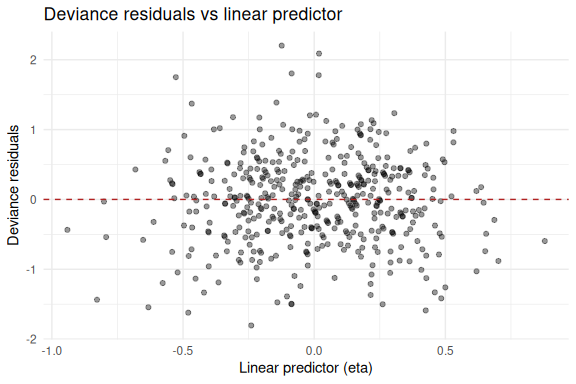

## Python

``` python
from plotnine import *

diag_df = recent.copy()
mu = fit_log1.predict()                          # 적합 확률 (mu)
diag_df["eta"] = fit_log1.model.family.link(mu)  # 연결함수로 선형 예측변수 복원
diag_df["dres"] = fit_log1.resid_deviance        # 이탈도 잔차

(
    ggplot(diag_df, aes("eta", "dres"))
    + geom_point(alpha=0.4)
    + geom_hline(yintercept=0, color="firebrick", linetype="dashed")
    + labs(x="Linear predictor (eta)", y="Deviance residuals",
           title="Deviance residuals vs linear predictor")
    + theme_minimal()
).show()
```

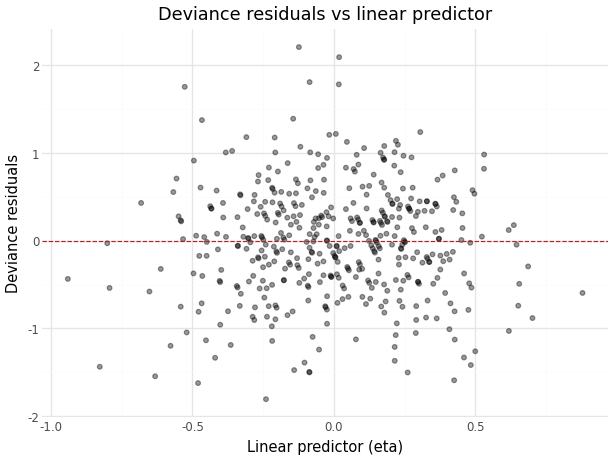

이탈도 잔차를 선형 예측변수에 대해 그린 그림에서는 점들이 0을 가운데
두고 위아래로 고르게 흩어져 있다. $\eta$가 커지는 쪽으로 휜다거나 분산이
벌어지는 패턴이 안 보이니, 한 모수짜리 함수 형태로 충분하다는 얘기다.
이탈도 해석(i)과 잔차 산점도(ii) 두 진단이 같은 결론을 가리킨다.

#### (4) `log(RA)`와 `log(RS)`를 따로 넣은 로지스틱 회귀

절편 없이 `logRA`와 `logRS`를 각각 따로 설명변수로 넣으면, 두 계수가 한
모수로 묶이지 않고 자유롭게 추정된다.

## R

``` r
fit_log2 <- glm(cbind(W, L) ~ logRA + logRS - 1, family = binomial, data = recent)
summary(fit_log2)$coef
```

           Estimate Std. Error   z value      Pr(>|z|)
    logRA -1.753561 0.04562946 -38.43047 3.952525e-323
    logRS  1.753153 0.04561853  38.43072 3.952525e-323

## Python

``` python
fit_log2 = smf.glm("W + L ~ logRA + logRS - 1", data=recent,
                   family=sm.families.Binomial()).fit()
print(fit_log2.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    logRA         -1.7536      0.046    -38.430      0.000      -1.843      -1.664
    logRS          1.7532      0.046     38.431      0.000       1.664       1.843
    ==============================================================================

`logRA` 계수는 -1.754, `logRS` 계수는 +1.753으로 나왔다. 크기는 거의
같고 부호만 반대다. 모형식의 로짓이 $k(\log RS - \log RA)$이니, 두
계수를 따로 풀어 줘도 자료가 알아서 $(+k, -k)$ 쪽으로 수렴한다. 결국
(1)의 비선형 최소제곱($\hat k = 1.753$), (2)의 단일 로지스틱
기울기(1.753), (4)의 두 계수 크기($\approx 1.753$)가 모두 같은 결과가
나왔다. 승률이 득점과 실점에 따로따로 휘둘리는 게 아니라 오직 그
비($RS/RA$)로만 결정된다는 Bill James의 가정이 제약을 풀어 준 모형에서도
자료에 의해 확인되었다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

문제 2-1과 같은 `recent` 자료에 이번엔 절편을 넣고 23개 설명변수를 전부
투입한 뒤 `stepAIC`로 양방향 선택을 돌렸다. R에는 `MASS::stepAIC`가
있지만 Python의 statsmodels에는 대응되는 함수가 없어서, AIC가 가장 많이
줄어드는 변수를 하나씩 떨궈 가는 후진 제거 함수를 직접 짜서 두 언어
결과를 맞췄다.

## R

``` r
f_full <- as.formula(
    paste("cbind(W, L) ~ logRS + logRA +", paste(vars_box, collapse = " + "))
)
fit_full <- glm(f_full, family = binomial, data = recent)
cat(
    "full model: residual deviance", round(deviance(fit_full), 2),
    "on", df.residual(fit_full), "df, AIC", round(AIC(fit_full), 1), "\n"
)
```

    full model: residual deviance 95.96 on 426 df, AIC 2627.2 

``` r
fit_step <- stepAIC(fit_full, trace = FALSE)
formula(fit_step)
```

    cbind(W, L) ~ logRS + logRA + CG + SHO + SV

``` r
round(summary(fit_step)$coef, 4)
```

                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -2.6940     0.8421  -3.1993   0.0014
    logRS         1.6153     0.0719  22.4720   0.0000
    logRA        -1.2842     0.1015 -12.6488   0.0000
    CG            0.0046     0.0030   1.5170   0.1293
    SHO           0.0047     0.0025   1.8451   0.0650
    SV            0.0111     0.0013   8.3845   0.0000

## Python

``` python
def step_aic_backward(df, lhs, predictors, family):
    """AIC가 가장 작아지는 변수를 하나씩 제거하는 후진 선택 (R stepAIC와 대응)."""
    cur = list(predictors)

    def fit(terms):
        formula = f"{lhs} ~ " + (" + ".join(terms) if terms else "1")
        return smf.glm(formula, data=df, family=family).fit()

    best_aic = fit(cur).aic
    improved = True
    while improved and cur:
        improved = False
        cand = sorted((fit([x for x in cur if x != t]).aic, t) for t in cur)
        if cand and cand[0][0] < best_aic:
            best_aic, drop = cand[0]
            cur = [x for x in cur if x != drop]
            improved = True
    return fit(cur), cur

preds = ["logRS", "logRA"] + r.vars_box
fit_full = smf.glm("W + L ~ " + " + ".join(preds), data=recent,
                   family=sm.families.Binomial()).fit()
print("full model: residual deviance", round(fit_full.deviance, 2),
      "on", int(fit_full.df_resid), "df, AIC", round(fit_full.aic, 1))
```

    full model: residual deviance 95.96 on 426 df, AIC 2627.2

``` python
fit_step, terms_step = step_aic_backward(recent, "W + L", preds, sm.families.Binomial())
print("selected:", terms_step)
```

    selected: ['logRS', 'logRA', 'CG', 'SHO', 'SV']

``` python
print(fit_step.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -2.6940      0.842     -3.199      0.001      -4.344      -1.044
    logRS          1.6153      0.072     22.472      0.000       1.474       1.756
    logRA         -1.2842      0.102    -12.649      0.000      -1.483      -1.085
    CG             0.0046      0.003      1.517      0.129      -0.001       0.010
    SHO            0.0047      0.003      1.845      0.065      -0.000       0.010
    SV             0.0111      0.001      8.384      0.000       0.009       0.014
    ==============================================================================

AIC 단계별 선택은 23개에서 `logRS`, `logRA`, `CG`(완투), `SHO`(완봉),
`SV`(세이브) 다섯 개만 남겼고, 두 언어가 똑같은 다섯을 골랐다. 그런데
문제가 요구한 대로, 남은 변수를 정말 다 둘지는 한 번 더 따져 봐야 한다.
계수의 Wald 검정을 보면 `logRS`(p≈0), `logRA`(p≈0), `SV`(p≈0)는 강하게
유의하지만 `CG`(p≈0.13)와 `SHO`(p≈0.065)는 5%에서 유의하지 않다. AIC는
표본이 크면 변수를 좀 헐겁게 남기는 버릇이 있어서, 이 둘을 빼도 되는지
우도비 검정으로 직접 확인했다. 먼저 둘을 한꺼번에 빼 보고, 그다음 하나씩
떼 본다.

## R

``` r
# (i) CG, SHO를 함께 뺀 모형과 우도비 검정으로 비교
fit_drop2 <- glm(cbind(W, L) ~ logRS + logRA + SV, family = binomial, data = recent)
anova(fit_drop2, fit_step, test = "Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ logRS + logRA + SV
    Model 2: cbind(W, L) ~ logRS + logRA + CG + SHO + SV
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       446     112.28                       
    2       444     106.12  2    6.159  0.04598 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# (ii) 둘 중 개별 유의성이 더 약한 CG만 제거
fit_final <- glm(cbind(W, L) ~ logRS + logRA + SHO + SV, family = binomial, data = recent)
anova(fit_final, fit_step, test = "Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ logRS + logRA + SHO + SV
    Model 2: cbind(W, L) ~ logRS + logRA + CG + SHO + SV
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)
    1       445     108.42                     
    2       444     106.12  1   2.3022   0.1292

``` r
round(summary(fit_final)$coef, 4)
```

                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -2.3597     0.8127  -2.9034   0.0037
    logRS         1.6062     0.0716  22.4244   0.0000
    logRA        -1.3221     0.0984 -13.4338   0.0000
    SHO           0.0050     0.0025   1.9638   0.0496
    SV            0.0107     0.0013   8.2491   0.0000

## Python

``` python
from scipy.stats import chi2

def lrt(reduced, full):
    stat = reduced.deviance - full.deviance
    df = int(reduced.df_resid - full.df_resid)
    return stat, df, chi2.sf(stat, df)

# (i) CG, SHO를 함께 제거
fit_drop2 = smf.glm("W + L ~ logRS + logRA + SV", data=recent,
                    family=sm.families.Binomial()).fit()
print("drop CG+SHO: LR=%.3f, df=%d, p=%.3f" % lrt(fit_drop2, fit_step))
```

    drop CG+SHO: LR=6.159, df=2, p=0.046

``` python
# (ii) CG만 제거
fit_final = smf.glm("W + L ~ logRS + logRA + SHO + SV", data=recent,
                    family=sm.families.Binomial()).fit()
print("drop CG only: LR=%.3f, df=%d, p=%.3f" % lrt(fit_final, fit_step))
```

    drop CG only: LR=2.302, df=1, p=0.129

``` python
print(fit_final.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -2.3597      0.813     -2.903      0.004      -3.953      -0.767
    logRS          1.6062      0.072     22.424      0.000       1.466       1.747
    logRA         -1.3221      0.098    -13.434      0.000      -1.515      -1.129
    SHO            0.0050      0.003      1.964      0.050    9.71e-06       0.010
    SV             0.0107      0.001      8.249      0.000       0.008       0.013
    ==============================================================================

개별 Wald 검정만 보면 `CG`와 `SHO`를 둘 다 떼어도 될 것 같지만, 막상
둘을 함께 뺀 모형과 우도비 검정을 해 보면 p-값이 0.046으로 5%에서
(아슬아슬하게) 유의하다. 즉 둘을 동시에 버리면 적합이 유의하게 나빠진다.
완투(`CG`)와 완봉(`SHO`)이 둘 다 “선발이 상대를 끝까지 틀어막았다”는
비슷한 정보를 담고 있어서, 함께 모형에 있을 때는 서로의 유의성을
갉아먹어 각자가 약해 보였던 것이다. 그래서 개별 유의성이 더 약한 `CG`만
떼었더니, `CG` 단독 제거의 우도비 p-값은 0.13으로 적합을 해치지 않았다.
확인할 만한 부분은 `CG`를 빼자마자 `SHO` 계수가 p=0.050으로 5%
경계선까지 올라온다는 점이다. 그래서 최종 모형은 `logRS`, `logRA`,
`SHO`, `SV` 네 변수에 절편이 있는 형태로 정했고, 이제 남은 변수는 전부
5%에서 유의하다.

이걸 2-1의 Bill James 모형과 비교하자면, 2-1 모형은 절편이 없고
`logRS`와 `logRA`의 계수가 $(+k, -k)$로 크기까지 강제로 묶여 있었다.
반면 최종 모형에서는 `logRS` 계수(약 1.61)와 `logRA` 계수(약 -1.32)의
크기가 같지 않다. 득점 쪽 가중치가 실점 쪽보다 조금 크게 추정되니,
승리에 대한 공격과 수비의 기여가 완전한 대칭은 아니라는 신호로 읽힌다.
게다가 완봉(`SHO`)과 세이브(`SV`)가 득실비만으로는 못 잡는 정보를
더해서, 같은 득실비라도 상대를 영봉으로 묶는 투수력이나 접전을 잠그는
불펜이 받쳐 주면 승수로 조금 더 잘 환산된다는 점을 짚어 준다. 그래도 큰
그림은 여전히 Bill James 모형이 더 나은 것 같다. 설명력의 대부분은
`logRS`(+)와 `logRA`(-)라는 득실비 신호에서 나오고, 박스스코어 변수들은
거기에 자잘한 보정을 얹을 뿐이다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### (1) 포아송 회귀

이번엔 비율 `WPct` 대신 승수 `W`를 직접 반응변수로 두고, 같은 23개
설명변수에 포아송 로그선형 모형을 적합한 뒤 `stepAIC`로 변수를 골랐다.

## R

``` r
f_pois <- as.formula(paste("W ~ logRS + logRA +", paste(vars_box, collapse = " + ")))
fit_pois <- glm(f_pois, family = poisson, data = recent)
cat(
    "residual deviance", round(deviance(fit_pois), 2),
    "on", df.residual(fit_pois), "df, AIC", round(AIC(fit_pois), 1), "\n"
)
```

    residual deviance 55.73 on 426 df, AIC 2903.6 

``` r
fit_pois_step <- stepAIC(fit_pois, trace = FALSE)
formula(fit_pois_step)
```

    W ~ logRS + ERA + CG + E + SV

``` r
round(summary(fit_pois_step)$coef, 4)
```

                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -0.3758     0.3477  -1.0808   0.2798
    logRS         0.7921     0.0507  15.6171   0.0000
    ERA          -0.1534     0.0135 -11.4004   0.0000
    CG            0.0034     0.0021   1.6325   0.1026
    E            -0.0006     0.0004  -1.7008   0.0890
    SV            0.0057     0.0009   6.1392   0.0000

## Python

``` python
preds = ["logRS", "logRA"] + r.vars_box
fit_pois = smf.glm("W ~ " + " + ".join(preds), data=recent,
                   family=sm.families.Poisson()).fit()
print("residual deviance", round(fit_pois.deviance, 2),
      "on", int(fit_pois.df_resid), "df, AIC", round(fit_pois.aic, 1))
```

    residual deviance 55.73 on 426 df, AIC 2903.6

``` python
fit_pois_step, terms_pois = step_aic_backward(recent, "W", preds, sm.families.Poisson())
print("selected:", terms_pois)
```

    selected: ['logRS', 'ERA', 'CG', 'E', 'SV']

``` python
print(fit_pois_step.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -0.3758      0.348     -1.081      0.280      -1.057       0.306
    logRS          0.7921      0.051     15.617      0.000       0.693       0.892
    ERA           -0.1534      0.013    -11.400      0.000      -0.180      -0.127
    CG             0.0034      0.002      1.633      0.103      -0.001       0.007
    E             -0.0006      0.000     -1.701      0.089      -0.001    9.15e-05
    SV             0.0057      0.001      6.139      0.000       0.004       0.008
    ==============================================================================

포아송 모형이 고른 변수는 `logRS`, `ERA`, `CG`, `E`(실책), `SV`
다섯이다. 2-2의 최종 로지스틱(`logRS`, `logRA`, `SHO`, `SV`)과 나란히
놓으면, 득점(`logRS`)과 세이브(`SV`)가 양쪽 모두에서 살아남는다는 점이
같다. 갈리는 건 실점을 어느 변수로 받느냐인데, 로지스틱은 `logRA`로
받았고 포아송은 같은 실점 정보를 다르게 보는 `ERA`(평균자책점)로
받았으며, 거기에 수비 실책(`E`)이 한 자리 더 들어왔다. 계수를 읽는
척도도 다르다. 포아송은 $\log E[W]$에 대한 선형모형이라 `logRS` 계수가
“득점이 1% 늘면 기대 승수가 몇 % 변하나” 하는 탄력성처럼 읽히고,
로지스틱은 승리 오즈의 로그에 대한 효과였다. 결국 두 모형은 “많이 치고,
덜 내주고 실책 적게, 세이브 챙기면 승리가 는다”는 의미를 서로 다른
모수화로 보여준다.

#### (2) 음이항 회귀

같은 설명변수로 음이항 회귀(`MASS::glm.nb`)를 시도했다. 음이항 회귀는
강의록(MASS ch07)에서 R로만 다루고 `statsmodels` 예시가 없어, 이 항만
R로 작성했다. 음이항은 산포모수 $\theta$를 함께 추정하는데, 적합
과정에서 경고가 줄줄이 뜨고 $\theta$ 추정치가 비정상적으로 커진다.
그래서 경고 메시지와 $\theta$ 값을 직접 잡아서 찍어 봤다.

In [ ]:
# glm.nb의 경고를 직접 포착해서 출력
nb_msgs <- character(0)
fit_nb <- withCallingHandlers(
    tryCatch(
        MASS::glm.nb(f_pois, data = recent),
        error = function(e) {
            nb_msgs <<- c(nb_msgs, paste("Error:", conditionMessage(e)))
            NULL
        }
    ),
    warning = function(w) {
        nb_msgs <<- c(nb_msgs, conditionMessage(w))
        invokeRestart("muffleWarning")
    }
)
cat("고유 경고 메시지:\n")

고유 경고 메시지:

[1] "iteration limit reached"


theta = 1.085204e+07  SE(theta) = 1.08564e+08 

R에서는 “iteration limit reached”, “alternation limit reached” 같은
경고가 반복해서 뜨면서 $\theta$ 추정치가 약 $1.1\times10^7$, 그러니까
사실상 무한대로 발산했다. 경고만 봐도 적합이 정상적으로 끝맺지 못했다는
게 드러난다.

원인은 자료가 과소산포라는 데 있다. 음이항 분포는 평균보다 분산이 큰
과대산포(overdispersion) 계수 자료를 위한 모형이고, 그 분산이
$\operatorname{var}(W) = \mu + \mu^2/\theta$라 $\theta$가 작을수록
분산이 부풀려진다. 그런데 (1)에서 봤듯이 설명변수를 다 넣고 나면 승수의
조건부 변동이 포아송이 기대하는 것보다도 작다(잔차 이탈도 55.7 ≪ 426).
부풀릴 과대산포가 애초에 없으니 음이항이 포아송 쪽으로 수렴하려 들고,
그건 $\theta \to \infty$($\alpha = 1/\theta \to 0$)라는 분포족의 경계에
해당한다. 경계에서는 최대우도 추정치가 유한하게 존재하지 않으므로 반복
알고리즘이 갈 곳을 잃고 한계 횟수에서 멈춘다. 뒤집어 보면, 음이항이
이렇게 “실패”한다는 사실 자체가 이 자료엔 음이항이 필요한 과대산포가
없다는 진단이다. 포아송이, 혹은 승수가 경기 수에 묶인다는 점까지
살리려면 이항이 더 알맞은 모형이라는 얘기다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

문제 2-1에서 로짓을 풀었던 힌트를 그대로 한 번 더 쓴다. 지수
$k + g\,I$에 로짓을 씌우면
$$\operatorname{logit}(WPct) = (k + g\,I)\log\frac{RS}{RA}
= k \cdot \underbrace{\log\frac{RS}{RA}}_{lr} + g \cdot \underbrace{I\cdot\log\frac{RS}{RA}}_{lr:steroid}$$
가 되어, `lr`과 “스테로이드 시대 지시변수 × `lr`” 두 항을 절편 없이 넣은
로지스틱 회귀로 떨어진다. `lr`의 계수가 $k$, 상호작용항의 계수가
$g$이고, $g=0$ 검정은 상호작용항 계수에 대한 보통의 Wald 검정으로 바로
끝난다. 자료는 1994–2005년과 2010–2025년을 합치되 2020년만 뺐다.

## R

``` r
two_era <- Teams %>%
    filter(
        (yearID >= 1994 & yearID <= 2005) | (yearID >= 2010 & yearID <= 2025),
        yearID != 2020
    ) %>%
    mutate(
        WPct = W / (W + L),
        lr = log(R / RA),
        steroid = as.integer(yearID >= 1994 & yearID <= 2005)
    ) %>%
    dplyr::select(yearID, W, L, WPct, lr, steroid)

cat(
    "관측치:", nrow(two_era),
    " (스테로이드 시대", sum(two_era$steroid), "/ 최근", sum(1 - two_era$steroid), ")\n"
)
```

    관측치: 802  (스테로이드 시대 352 / 최근 450 )

``` r
fit_24 <- glm(cbind(W, L) ~ lr + lr:steroid - 1, family = binomial, data = two_era)
summary(fit_24)$coef
```

                Estimate Std. Error   z value      Pr(>|z|)
    lr         1.7532035 0.04561729 38.432871 3.952525e-323
    lr:steroid 0.1615666 0.07475132  2.161388  3.066536e-02

``` r
confint(fit_24)
```

                    2.5 %    97.5 %
    lr         1.66387948 1.8426980
    lr:steroid 0.01509905 0.3081213

## Python

``` python
two_era = r.two_era.copy()
print("관측치:", len(two_era))
```

    관측치: 802

``` python
fit_24 = smf.glm("W + L ~ lr + lr:steroid - 1", data=two_era,
                 family=sm.families.Binomial()).fit()
print(fit_24.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    lr             1.7532      0.046     38.433      0.000       1.664       1.843
    lr:steroid     0.1616      0.075      2.161      0.031       0.015       0.308
    ==============================================================================

`lr`의 계수(=$k$)는 1.753이고 상호작용항(=$g$)은 0.162, 표준오차 0.075,
$z = 2.16$, p-값 0.031로 추정됐다. p-값이 0.05보다 작으니 5%
유의수준에서 $g = 0$이라는 귀무가설을 기각한다. 두 시대의 $k$가 유의하게
다르다고 볼 수 있다는 뜻이다.

주목할 부분은 부호가 양수라는 점이다. 스테로이드 시대의 지수는
$k + g \approx 1.753 + 0.162 = 1.915$로 최근(1.753)보다 높다. 지수가
크다는 건 승률–득실비 곡선이 득실비 1 근방에서 더 가파르다는 뜻이라,
같은 크기의 득점 우위가 그 시절엔 더 큰 승률 차이로 환산됐다는 이야기가
된다. 풀어 말하면 1994–2005년에는 득실 차이가 승패를 좀 더 결정적으로
갈랐다. 다만 p-값이 0.031이라 5%에선 유의하지만 1% 문턱은 넘지 못하니,
차이가 있다고는 말하되 그 강도를 부풀리지는 않는 편이 정직하다.
신뢰구간은 R이 `confint()`의 프로파일 구간, Python이 Wald 구간이라 계산
방식은 다르지만, $g$의 구간이 R에서 (0.0151, 0.3081), Python에서
\[0.015, 0.308\]로 끝자리까지 사실상 같게 나왔다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 Quarto 소스(`hw02.qmd`)를 올리면
GitHub가 알아서 HTML과 주피터 노트북(`.ipynb`)을 만들고 이를 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)로 띄우도록 했다.
숙제 3에서는 거기에 한 단계를 더 얹는다. 분석 환경(conda + R 패키지)을
담은 컨테이너 이미지를 GitHub Actions가 GHCR(GitHub Container
Registry)에 올리고, `gh-pages`에는 그 이미지를 `FROM` 하는 얇은
`Dockerfile`과 노트북을 함께 배포해, [Binder](https://mybinder.org)가
미리 만들어 둔 이미지를 그대로 받아 온라인에서 `hw03.ipynb`를 실행할 수
있게 만드는 것이 목표다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

``` yaml
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}

# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888
```

### 답안

위에서 제공된 `Dockerfile` 원본에 몇 가지 수정을 반영해 커밋했다.
`ENV RETICULATE_PYTHON`으로 Python 경로를 고정해, 이전 과제에서부터
setup 청크에 넣어 둔 `Sys.getenv("RETICULATE_PYTHON")` 분기가 컨테이너
안에서 이 값을 집어 로컬과 똑같이 reticulate가 돌게 했다. 빌드 중 두
가지 오류를 만나 손봤는데, 하나는 `IRkernel`이 의존하는 `pbdZMQ`가
`libzmq.so.5`를 못 찾는 문제라 시스템 패키지에 `libzmq3-dev`를 추가했고,
다른 하나는 conda가 기본 채널 약관(ToS) 미동의로 멈추는 문제라
`-c conda-forge --override-channels`로 conda-forge만 쓰게 했다. 패키지는
이전 `publish.yml`과 동일한 두 언어의 `*-packages.txt`을 그대로 읽어
설치하도록 바꿔, CI와 이미지가 같은 목록을 보게 했다.

원본 템플릿은 `COPY _site/hw03.ipynb`로 노트북을 이미지에 구워 넣었지만,
그러면 노트북이 바뀔 때마다 무거운 환경 이미지를 통째로 다시 빌드해야
한다. 그래서 이 `Dockerfile`은 분석 환경만 담는 이미지로 두고 노트북은
복사하지 않았다. 노트북은 뒤(문제 3-3)에서 Binder가 이 이미지를 `FROM`
한 간단한 `Dockerfile`로 그때그때 얹는다.

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

``` yaml
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
```

### 답안

숙제 2의 `publish.yml`(Quarto 렌더 후 `gh-pages`로 배포하던 워크플로우)
끝에, 문제에서 준 GHCR 로그인·빌드·푸시 단계를 이어 붙였다. 이때 현재
리포지토리가 `snu-stat` 조직 소속이라 자동 발급되는 `GITHUB_TOKEN`으로는
`ghcr.io/snu-stat/...`에 패키지를 만들 권한이 없어 푸시가
막힌다(Classroom 조직 제한). 그래서 푸시 대상을 내 개인 네임스페이스
`ghcr.io/cos18/my-r-env`로 바꾸고, `write:packages` 권한을 가진 개인
토큰(PAT)을 시크릿 `GHCR_PAT`로 등록해 그걸로 로그인하도록 했다. 이
토큰은 유효기간이 있어 만료되면 재발급해 저장소 시크릿을 갱신해야 한다.

또 커밋마다 이미지를 통째로 다시 빌드하지 않도록, `Dockerfile`과 두
`*-packages.txt`의 해시 앞 6글자를 이미지 태그로 쓴다. 환경이 그대로면
같은 태그가 GHCR에 이미 있으므로 `docker buildx imagetools inspect`로
존재를 확인해 빌드 단계를 건너뛴다. 노트북은 이미지에 굽지 않으니, 배포
직전에 `_site/Dockerfile`을 `FROM ghcr.io/cos18/my-r-env:<해시>` +
`COPY hw03.ipynb` 형태로 만들어 `gh-pages`에 함께 올린다(다음 문제에서
Binder가 이걸 쓴다).

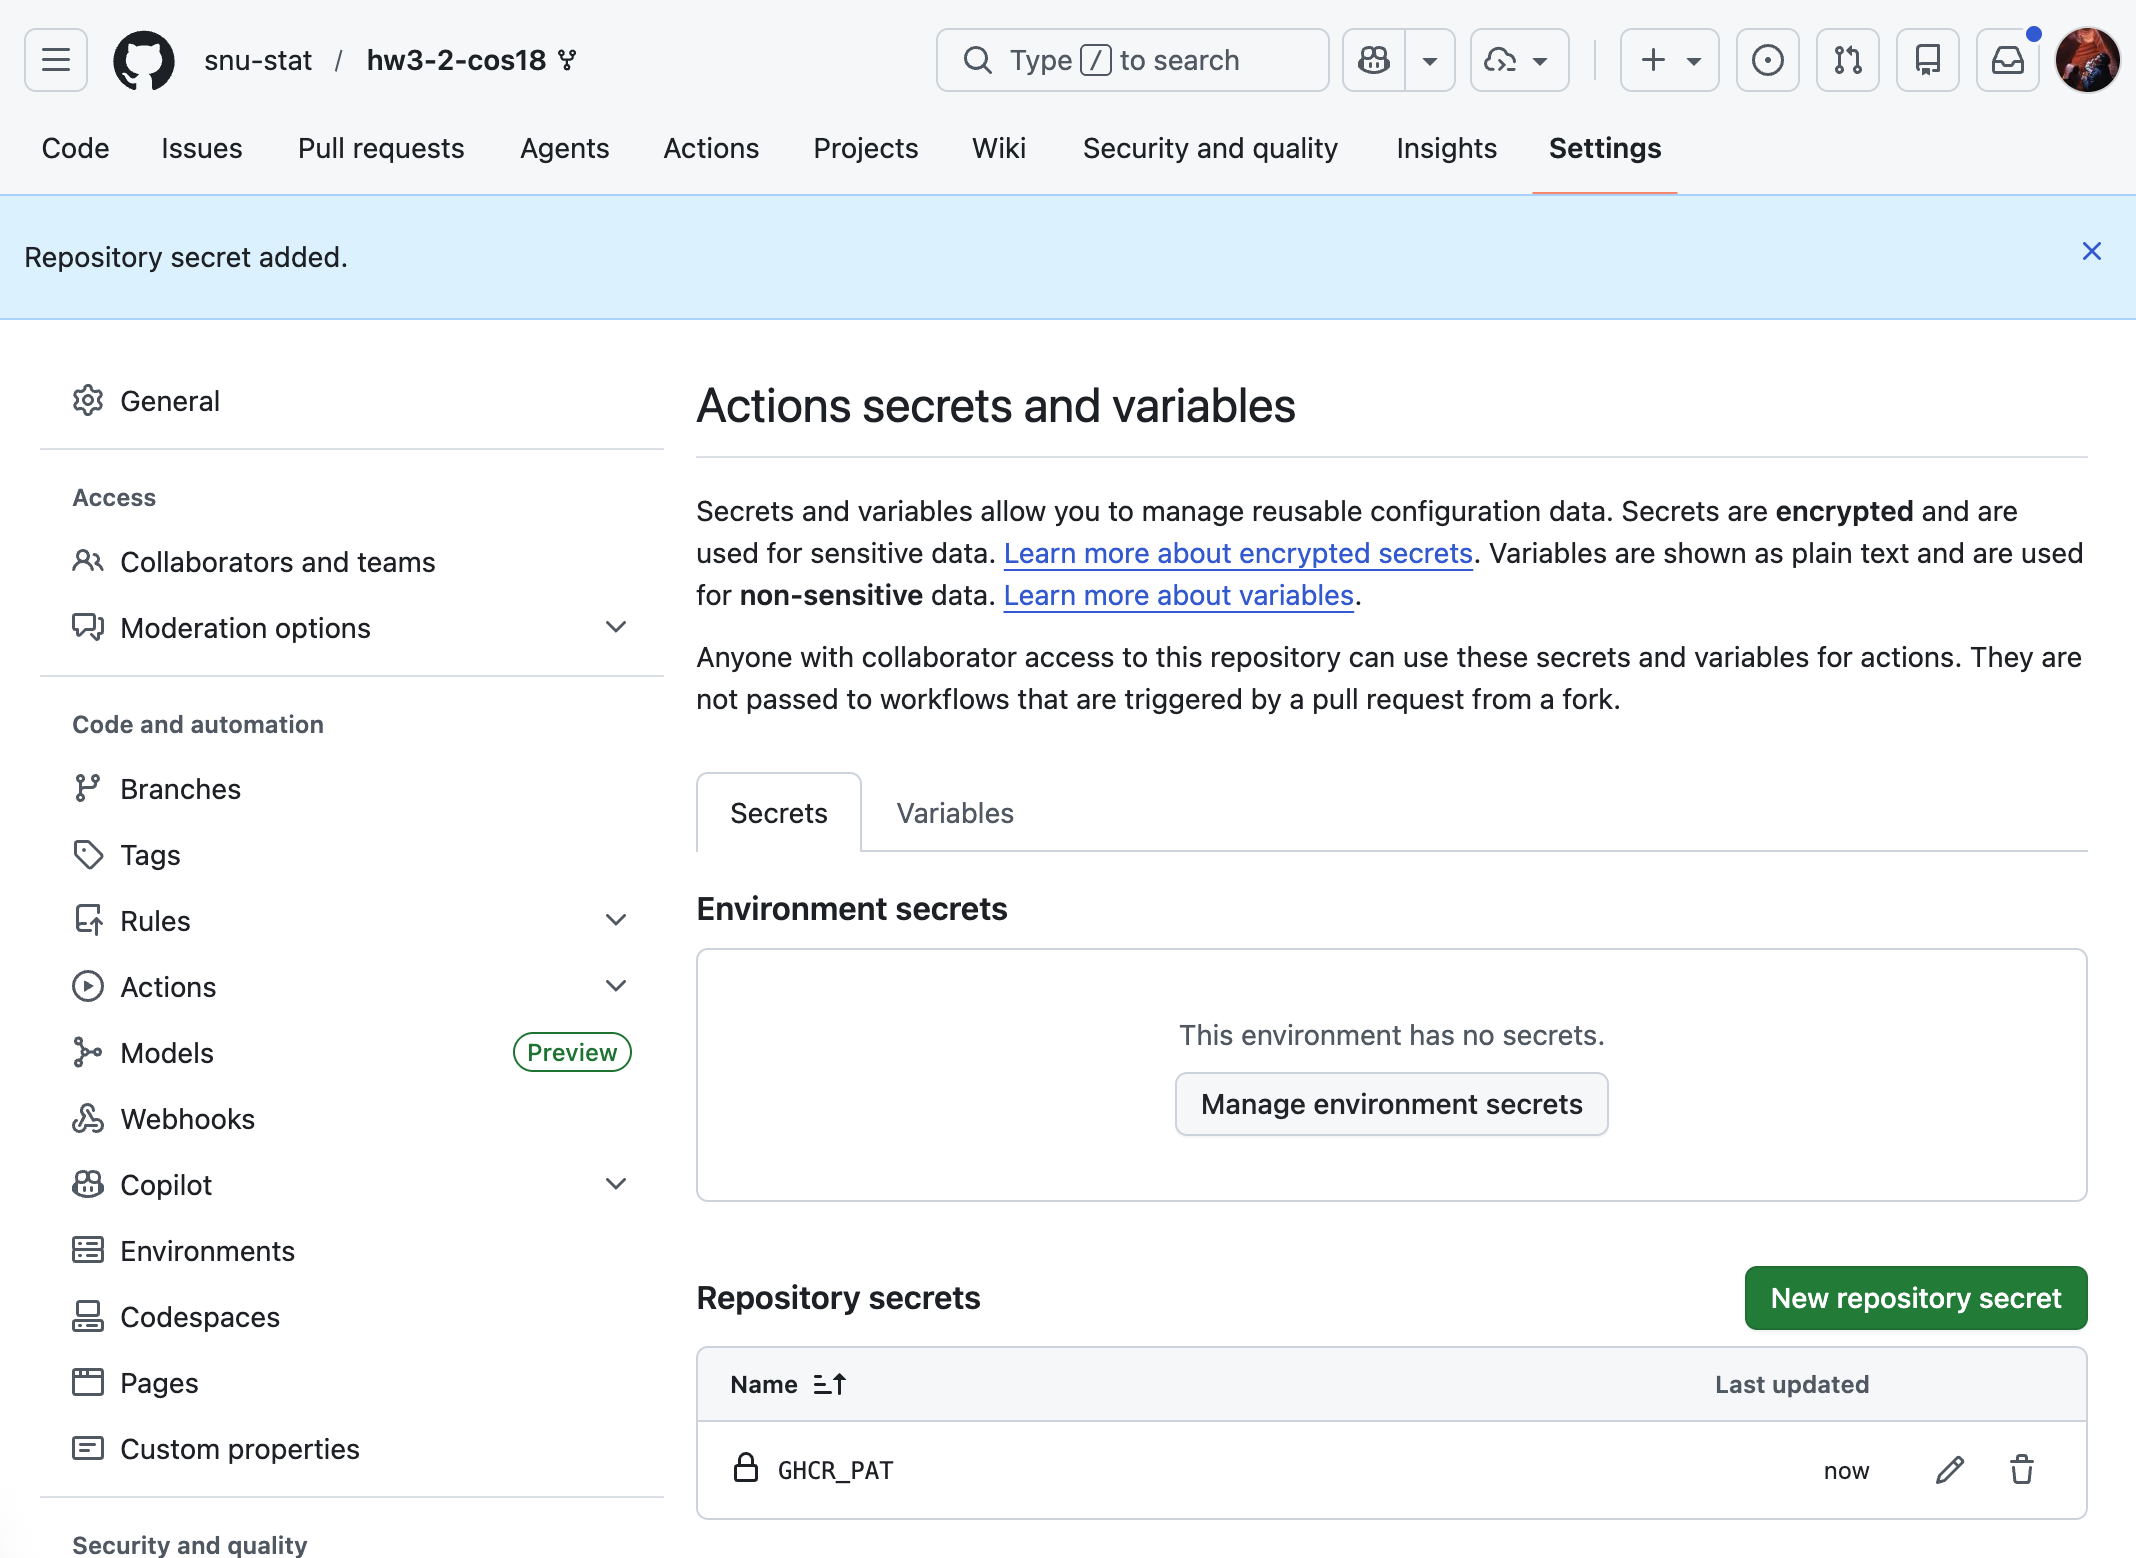

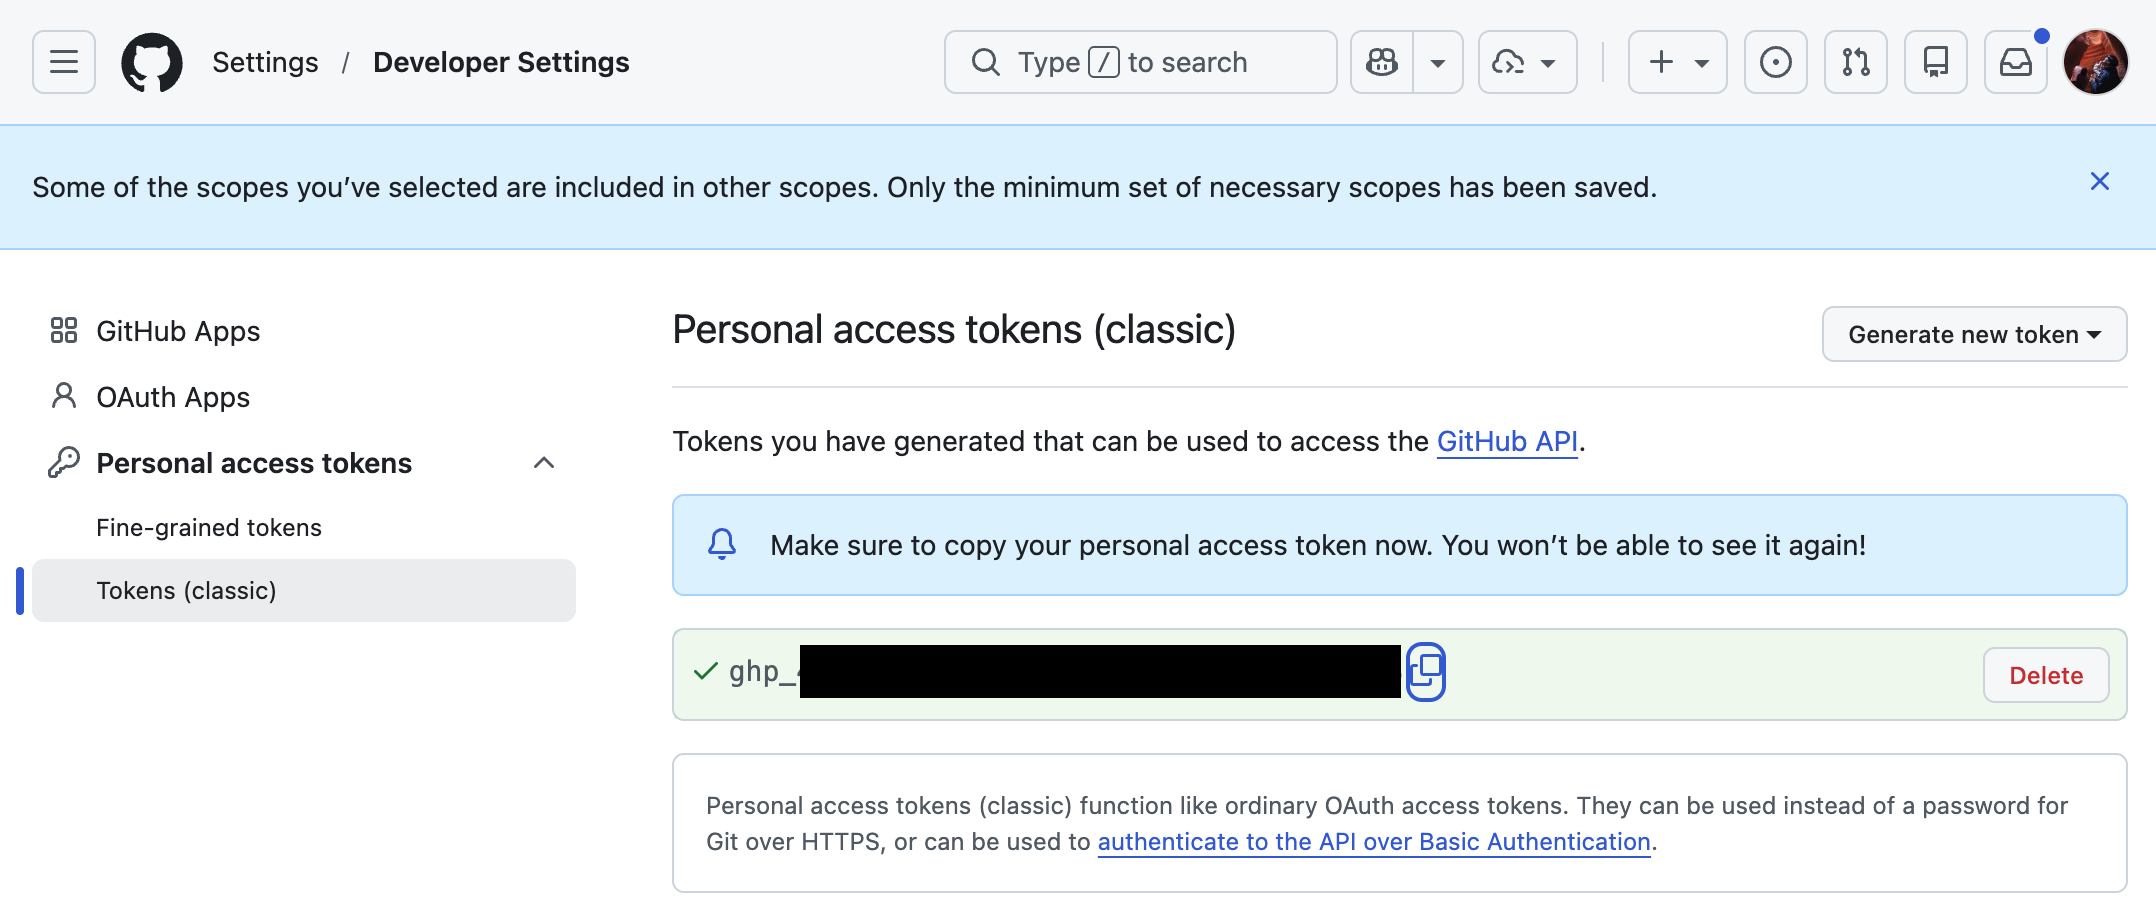

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

``` markdown
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html)
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb
```

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

`README.md`에 이름·학번과 함께 분석 리포트(HTML)와 노트북(Binder) 링크
절을 더했다. 노트북은 다운로드가 아니라 Binder URL로 걸었고, GitHub
Classroom 배지와 안내사항은 그대로 두었다. `publish.yml`의 “Prepare
README as Index” 단계가 이 `README.md`를 `index.md`로 복사해 Pages 첫
화면으로 쓴다.

Binder 링크는 처음에 GHCR 이미지를 바로 받는
`v2/ghcr/cos18/my-r-env/...` 형식으로 적었다가 접속해 보니 404가 났다.
확인해 보니 mybinder.org에는 레지스트리 이미지를 URL로 곧장 실행하는
`ghcr` 프로바이더가 없어서 그 주소 자체가 인식되지 않는다. mybinder에서
미리 만든 이미지를 쓰는 정석은, Binder가 실행할 브랜치에 그 이미지를
`FROM` 하는 간단한 `Dockerfile`을 두는 것이다(이때 `FROM` 태그로
`latest`는 repo2docker가 거부하므로 환경 해시 태그를 쓴다). 그래서
`publish.yml`이 `gh-pages`에 `FROM ghcr.io/cos18/my-r-env:<해시>` +
`COPY hw03.ipynb`짜리 `Dockerfile`과 노트북을 함께 배포하고, 링크는 그
`gh-pages`를 가리키는 `gh` 형식으로 적었다. Binder는 이 간단한
`Dockerfile`을 빌드하면서 미리 만들어 둔 환경 이미지를 그대로
끌어오고(무거운 설치 없이 빠름) 노트북만 얹는다. 실제 `README.md`의 링크
부분은 다음과 같다.

``` markdown
# Homework 3
**제출마감 2026-06-15 23:00**

이름: 박성우
학번: 2025-22279

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html)
* [주피터 노트북 (Binder)](https://mybinder.org/v2/gh/snu-stat/hw3-2-cos18/gh-pages?filepath=hw03.ipynb)
```